# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

##  Data Task
**The objective** is to create a data-driven model that allows establishing the correlation and measure the changes and/or variations in car attributes like **year, manufacturer, model, condition, odometer reading** influence or are associated with car price. 


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Data Understanding 
- Understanding and assessing the data columns and its definitions.
- Preview of the data and checking the dimensions
- Check the Missing values and its percentange of missing values

In [8]:
#Add the imports here
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from scipy.stats import zscore
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [9]:

data = pd.read_csv('data/vehicles.csv')
data.head()
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

(426880, 18)

In [10]:
print(data.isnull().sum())
print(data.isnull().mean() * 100)

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64
id               0.000000
region           0.000000
price            0.000000
year             0.282281
manufacturer     4.133714
model            1.236179
condition       40.785232
cylinders       41.622470
fuel             0.705819
odometer         1.030735
title_status     1.930753
transmission     0.598763
VIN             37.725356
drive           30.586347
size            71.767476
type            21.752717
paint_color     30.501078
state            0.000000
dtype: float64


In [11]:
# Identify and drop duplicate rows 
# Remove row with 0 price 
#print(data.duplicated().sum())

cnt = data[data['price'] == 0].shape[0]
print(cnt)

#price being zero for 7.7% of total record  32895 is x% of 426880, seems like it safe to drop otherwise 
# Drop rows with price == 0 

data_clean = data[data['price'] != 0]
data_clean.shape


32895


(393985, 18)

In [12]:
# Drop columns that are having NULL values and are not significant for our EDA process
# We will drop ID, size columns as size has 70% of data null. 

data_clean = data_clean.drop(['id','size','VIN'], axis=1)
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393985 entries, 0 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        393985 non-null  object 
 1   price         393985 non-null  int64  
 2   year          392812 non-null  float64
 3   manufacturer  377800 non-null  object 
 4   model         389284 non-null  object 
 5   condition     242596 non-null  object 
 6   cylinders     233575 non-null  object 
 7   fuel          391391 non-null  object 
 8   odometer      391695 non-null  float64
 9   title_status  386251 non-null  object 
 10  transmission  392162 non-null  object 
 11  drive         273731 non-null  object 
 12  type          308053 non-null  object 
 13  paint_color   276836 non-null  object 
 14  state         393985 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 48.1+ MB


In [13]:
# Lets address Missing data and conversion of dtypes. Convert year to integer after imputing the year data for missing records.

mean_year = data_clean['year'].mean()
median_year =int( data_clean['year'].median(skipna=True))

#convert year from float to int
data_clean['year'] = data_clean['year'].fillna(median_year).astype(int)

print(data_clean['year'].dtype)

# Lets Fill NaN based on the most frequent 'drive' for each 'type' group
data['drive'] = data.groupby('type')['drive'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))



int32


In [14]:
#Impute function for odometer

data_clean = data_clean.dropna(subset=['odometer'])

# Define odometer ranges (bins)
bins = [0, 50000, 100000, 150000, np.inf]
labels = ['low', 'medium', 'high', 'very_high']
data_clean['odometer_range'] = pd.cut(data_clean['odometer'], bins=bins, labels=labels)

# Define year ranges (bins)
year_bins = [1900, 1925,1950,1975, 2000, 2010, 2020, np.inf]
year_labels = ['oldest','older','old','somewhatold','pre_recent', 'recent','new']
data_clean['year_range'] = pd.cut(data_clean['year'], bins=year_bins, labels=year_labels)

# Group by odometer_range and year_range, and compute mode for condition
data_clean['condition'] = data_clean.groupby(['odometer_range','year_range'],observed=True)['condition'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

#Lets impute odometer values for missing data
pd.set_option('future.no_silent_downcasting', True)
data_clean['odometer'] = data_clean.groupby('year')['odometer'].transform(lambda x: x.fillna(x.mode()[0] if not  x.mode().empty else 'Unknown'))



In [15]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391695 entries, 27 to 426879
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   region          391695 non-null  object  
 1   price           391695 non-null  int64   
 2   year            391695 non-null  int32   
 3   manufacturer    375623 non-null  object  
 4   model           387062 non-null  object  
 5   condition       390569 non-null  object  
 6   cylinders       232516 non-null  object  
 7   fuel            389372 non-null  object  
 8   odometer        391695 non-null  float64 
 9   title_status    384231 non-null  object  
 10  transmission    390175 non-null  object  
 11  drive           271966 non-null  object  
 12  type            306247 non-null  object  
 13  paint_color     275588 non-null  object  
 14  state           391695 non-null  object  
 15  odometer_range  390581 non-null  category
 16  year_range      391683 non-null  category


In [16]:
#lets convert categorical data to numeric data
unique_values_for_cylinder= data_clean['cylinders'].unique()
#print(unique_values_for_cylinder, unique_values_for_condition)
data_clean.loc[:, 'cylinders'] = data_clean['cylinders'].fillna('unknown')

# Perform one-hot encoding
encoded_data = pd.get_dummies(data_clean['cylinders'], prefix='cylinders').astype(int)

# Combine with original DataFrame
data_clean = pd.concat([data_clean.drop('cylinders', axis=1), encoded_data], axis=1)
data_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 391695 entries, 27 to 426879
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   region                  391695 non-null  object  
 1   price                   391695 non-null  int64   
 2   year                    391695 non-null  int32   
 3   manufacturer            375623 non-null  object  
 4   model                   387062 non-null  object  
 5   condition               390569 non-null  object  
 6   fuel                    389372 non-null  object  
 7   odometer                391695 non-null  float64 
 8   title_status            384231 non-null  object  
 9   transmission            390175 non-null  object  
 10  drive                   271966 non-null  object  
 11  type                    306247 non-null  object  
 12  paint_color             275588 non-null  object  
 13  state                   391695 non-null  object  
 14  odometer

In [17]:
#lets convert categorical data to numeric data - Condition
unique_values_for_condition = data_clean['condition'].unique()
print(unique_values_for_condition)

data_clean.loc[:, 'condition'] = data_clean['condition'].fillna('missing')

# Perform one-hot encoding
encoded_condition = pd.get_dummies(data_clean['condition'], prefix='condition').astype(int)

# Combine with original DataFrame
data_clean = pd.concat([data_clean, encoded_condition], axis=1)

#fill the null values of Drive data
data_clean['drive'] = data_clean['drive'].fillna('Unknown')

#Lets convert the drive data to one hot encoding 
encoded_drive = pd.get_dummies(data_clean['drive'], prefix='drive').astype(int)

#Combine with original Dataframe
data_clean = pd.concat([data_clean, encoded_drive], axis=1)

data_clean.info()


['good' 'excellent' 'fair' 'like new' 'new' nan 'salvage' 'Unknown']
<class 'pandas.core.frame.DataFrame'>
Index: 391695 entries, 27 to 426879
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   region                  391695 non-null  object  
 1   price                   391695 non-null  int64   
 2   year                    391695 non-null  int32   
 3   manufacturer            375623 non-null  object  
 4   model                   387062 non-null  object  
 5   condition               391695 non-null  object  
 6   fuel                    389372 non-null  object  
 7   odometer                391695 non-null  float64 
 8   title_status            384231 non-null  object  
 9   transmission            390175 non-null  object  
 10  drive                   391695 non-null  object  
 11  type                    306247 non-null  object  
 12  paint_color             275588 non-null  object  

In [18]:
#For model to perfoman on year data , lets create another column as car_age
#Get the current year
current_year = datetime.now().year

# Create a new column 'car_age' by subtracting the 'year' from the current year
data_clean.loc[:,'car_age'] = current_year - data_clean['year']


In [19]:
#lets rename the columns for better readability 
data_clean = data_clean.rename(columns={'cylinders_10 cylinders': 'cylinders_10'})
data_clean = data_clean.rename(columns={'cylinders_12 cylinders': 'cylinders_12'})
data_clean = data_clean.rename(columns={'cylinders_3 cylinders': 'cylinders_3'})
data_clean = data_clean.rename(columns={'cylinders_4 cylinders': 'cylinders_4'})
data_clean = data_clean.rename(columns={'cylinders_5 cylinders': 'cylinders_5'})
data_clean = data_clean.rename(columns={'cylinders_6 cylinders': 'cylinders_6'})
data_clean = data_clean.rename(columns={'cylinders_8 cylinders': 'cylinders_8'})
data_clean = data_clean.rename(columns={'condition_like new': 'condition_like_new'})

data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391695 entries, 27 to 426879
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   region               391695 non-null  object  
 1   price                391695 non-null  int64   
 2   year                 391695 non-null  int32   
 3   manufacturer         375623 non-null  object  
 4   model                387062 non-null  object  
 5   condition            391695 non-null  object  
 6   fuel                 389372 non-null  object  
 7   odometer             391695 non-null  float64 
 8   title_status         384231 non-null  object  
 9   transmission         390175 non-null  object  
 10  drive                391695 non-null  object  
 11  type                 306247 non-null  object  
 12  paint_color          275588 non-null  object  
 13  state                391695 non-null  object  
 14  odometer_range       390581 non-null  category
 15  year

In [20]:
data_clean.head(10)

,region,price,year,manufacturer,model,condition,fuel,odometer,title_status,transmission,...,condition_good,condition_like_new,condition_missing,condition_new,condition_salvage,drive_4wd,drive_Unknown,drive_fwd,drive_rwd,car_age
27,auburn,33590,2014,gmc,sierra 1500 crew cab slt,good,gas,57923.0,clean,other,...,1,0,0,0,0,0,1,0,0,10
28,auburn,22590,2010,chevrolet,silverado 1500,good,gas,71229.0,clean,other,...,1,0,0,0,0,0,1,0,0,14
29,auburn,39590,2020,chevrolet,silverado 1500 crew,good,gas,19160.0,clean,other,...,1,0,0,0,0,0,1,0,0,4
30,auburn,30990,2017,toyota,tundra double cab sr,good,gas,41124.0,clean,other,...,1,0,0,0,0,0,1,0,0,7
31,auburn,15000,2013,ford,f-150 xlt,excellent,gas,128000.0,clean,automatic,...,0,0,0,0,0,0,0,0,1,11
32,auburn,27990,2012,gmc,sierra 2500 hd extended cab,good,gas,68696.0,clean,other,...,1,0,0,0,0,1,0,0,0,12
33,auburn,34590,2016,chevrolet,silverado 1500 double,good,gas,29499.0,clean,other,...,1,0,0,0,0,1,0,0,0,8
34,auburn,35000,2019,toyota,tacoma,excellent,gas,43000.0,clean,automatic,...,0,0,0,0,0,1,0,0,0,5
35,auburn,29990,2016,chevrolet,colorado extended cab,good,gas,17302.0,clean,other,...,1,0,0,0,0,1,0,0,0,8
36,auburn,38590,2011,chevrolet,corvette grand sport,good,gas,30237.0,clean,other,...,1,0,0,0,0,0,0,0,1,13


In [21]:
price_stats = data_clean['price'].describe()
print(price_stats)

count    3.916950e+05
mean     8.184865e+04
std      1.271765e+07
min      1.000000e+00
25%      7.000000e+03
50%      1.523000e+04
75%      2.759000e+04
max      3.736929e+09
Name: price, dtype: float64


,price,year,odometer,cylinders_10,cylinders_12,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,...,condition_good,condition_like_new,condition_missing,condition_new,condition_salvage,drive_4wd,drive_Unknown,drive_fwd,drive_rwd,car_age
count,5.300000e+01,53.000000,5.300000e+01,53.0,53.0,53.0,53.000000,53.0,53.000000,53.000000,...,53.000000,53.000000,53.000000,53.000000,53.0,53.000000,53.000000,53.000000,53.000000,53.000000
mean,4.649499e+08,1989.169811,3.704945e+05,0.0,0.0,0.0,0.037736,0.0,0.075472,0.320755,...,0.603774,0.094340,0.018868,0.037736,0.0,0.283019,0.566038,0.094340,0.056604,34.830189
std,9.990088e+08,27.339557,1.376031e+06,0.0,0.0,0.0,0.192380,0.0,0.266679,0.471233,...,0.493793,0.295098,0.137361,0.192380,0.0,0.454776,0.500363,0.295098,0.233295,27.339557
min,1.111111e+06,1902.000000,0.000000e+00,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,3.000000
25%,1.234567e+06,1960.000000,9.999900e+04,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,14.000000
50%,1.234568e+07,1999.000000,1.000000e+05,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.000000,25.000000
75%,1.234568e+08,2010.000000,1.640000e+05,0.0,0.0,0.0,0.000000,0.0,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.0,1.000000,1.000000,0.000000,0.000000,64.000000
max,3.736929e+09,2021.000000,9.999999e+06,0.0,0.0,0.0,1.000000,0.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,122.000000


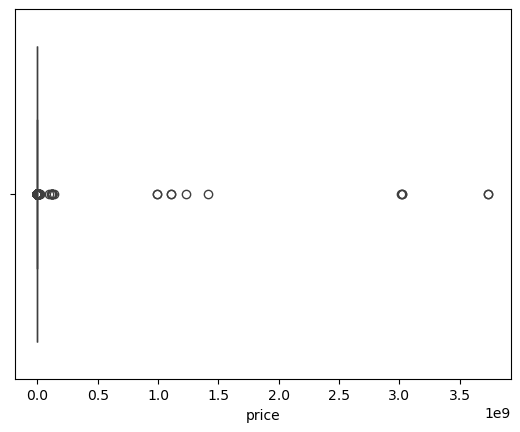

In [22]:
sns.boxplot(data=data_clean, x='price')
data_clean[(data_clean['price'] > 1000000)].describe()

In [23]:
# to find the ranges to see how the distribution of prices for the car are
bin_edges = [0, 5000, 10000, 15000, 20000, 30000, 50000, 100000, 200000, 250000]
bin_labels = ['0-5k', '5k-10k', '10k-15k', '15k-20k', '20k-30k', '30k-50k', '50k-100k', '100k-200K','200K+']

data_clean['price_range'] = pd.cut(data_clean['price'], bins=bin_edges, labels=bin_labels, include_lowest=True)
price_ranges = data_clean['price_range'].value_counts().sort_index()
print(price_ranges)

price_range
0-5k         63907
5k-10k       78540
10k-15k      53288
15k-20k      48318
20k-30k      69200
30k-50k      65618
50k-100k     12176
100k-200K      524
200K+           29
Name: count, dtype: int64


In [24]:
data_clean['price_range']

27        30k-50k
28        20k-30k
29        30k-50k
30        30k-50k
31        10k-15k
           ...   
426875    20k-30k
426876    30k-50k
426877    30k-50k
426878    20k-30k
426879    30k-50k
Name: price_range, Length: 391695, dtype: category
Categories (9, object): ['0-5k' < '5k-10k' < '10k-15k' < '15k-20k' ... '30k-50k' < '50k-100k' < '100k-200K' < '200K+']

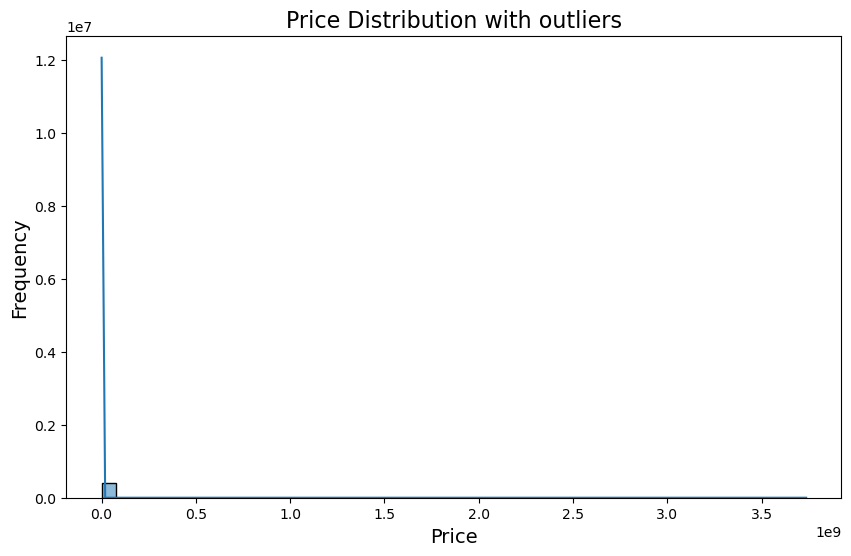

In [25]:
# histogram for price distribution

plt.figure(figsize=(10, 6))
hist = sns.histplot(data_clean['price'],kde=True, bins=50)
# Customize the plot
plt.title('Price Distribution with outliers', fontsize=16)
plt.xlabel('Price', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
#plt.xlim(0, 10000) 
plt.show()
hist.figure.savefig('images/price_hist_withOLchart.png')

In [26]:
# Lets find the outlier and see if we can remove those
Q1 = data_clean['price'].quantile(0.20)
Q3 = data_clean['price'].quantile(0.80)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
outliers = data_clean[(data_clean['price'] >= lower_bound) | (data_clean['price'] <= upper_bound)]
data_clean = data_clean[(data_clean['price'] >= lower_bound) & (data_clean['price'] <= upper_bound)]
data_clean.reset_index(drop=True, inplace=True)



Lower Bound: -30680.800000000017, Upper Bound: 67132.00000000003


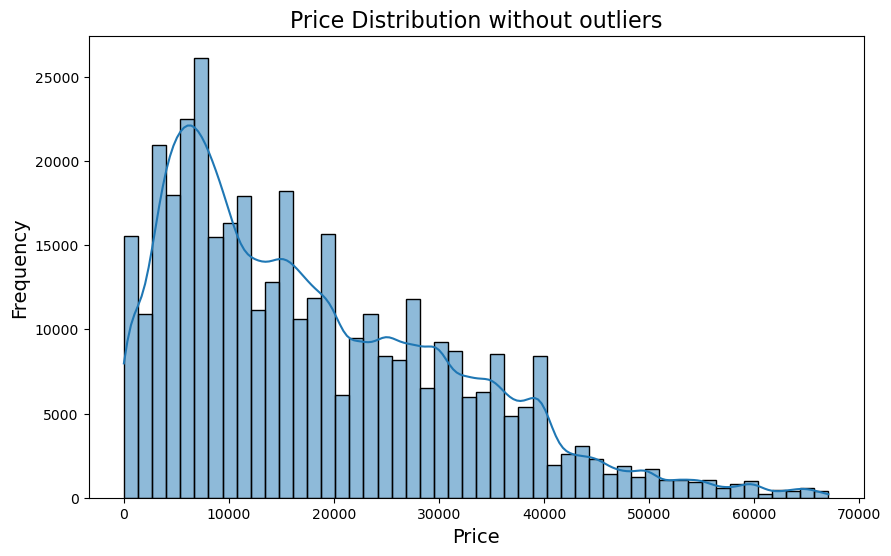

In [27]:
plt.figure(figsize=(10, 6))
hist = sns.histplot(data_clean['price'],kde=True, bins=50)
# Customize the plot
plt.title('Price Distribution without outliers', fontsize=16)
plt.xlabel('Price', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
hist.figure.savefig('images/price_hist_withoutOLchart.png')

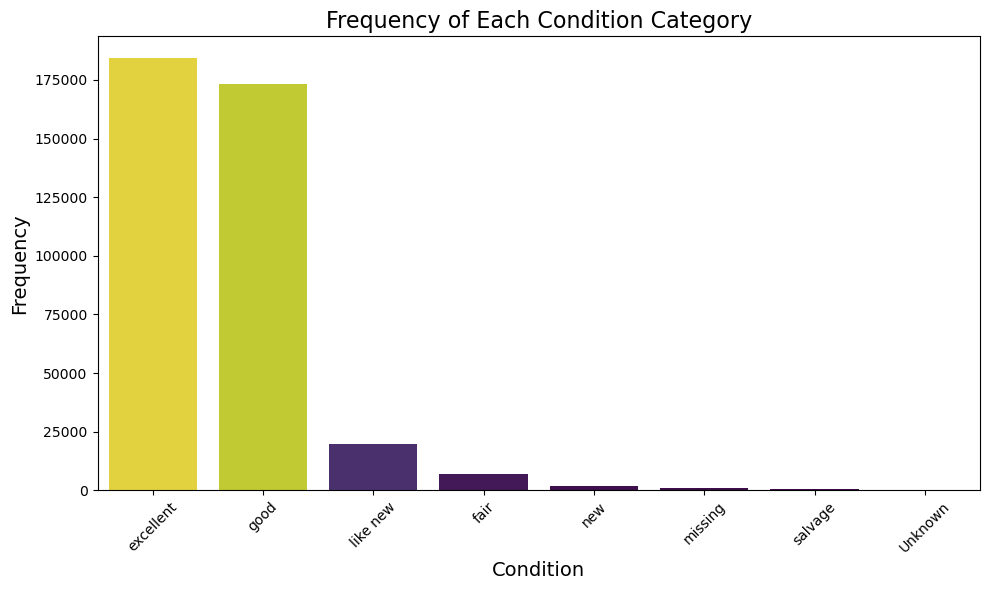

In [28]:
#Lets explore other variables to see the distribution
# Count the frequency of each condition category
condition_counts = data_clean['condition'].value_counts()

# Plotting the bar plot
plt.figure(figsize=(10, 6))
hist= sns.barplot(x=condition_counts.index, y=condition_counts.values, palette='viridis',hue=condition_counts,legend=False)
plt.title('Frequency of Each Condition Category', fontsize=16)
plt.xlabel('Condition', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

hist.figure.savefig('images/conditon_hist_chart.png')

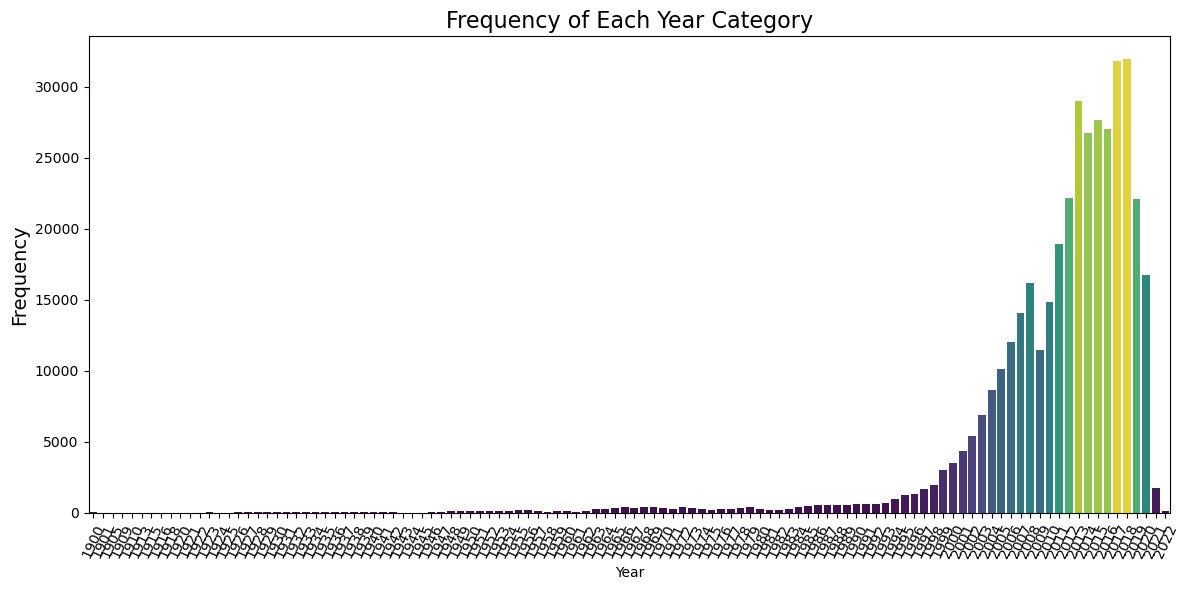

In [29]:
#Lets explore other variables to see the distribution
# Count the frequency of each condition category
year_counts = data_clean['year'].value_counts()

# Plotting the bar plot
plt.figure(figsize=(12, 6))
hist= sns.barplot(x=year_counts.index, y=year_counts.values, palette='viridis',hue=year_counts,legend=False)
plt.title('Frequency of Each Year Category', fontsize=16)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=65)
plt.tight_layout()
plt.show()

hist.figure.savefig('images/year_hist_chart.png')

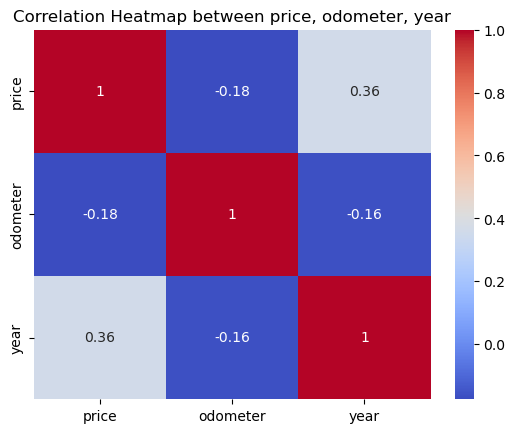

In [30]:
# Correlation heatmap between price, odomter, year
correlation_matrix = data_clean[['price', 'odometer', 'year']].corr()

heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap between price, odometer, year')
plt.show()
heatmap.figure.savefig('images/heatmap_bw_price_odometer_year.png')


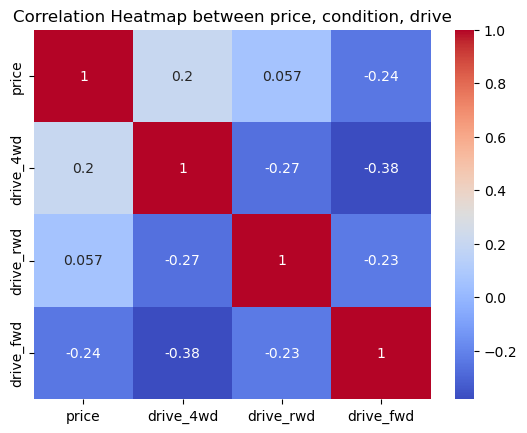

In [31]:
# Correlation heatmap between price, condition, drive
correlation_matrix_2 = data_clean[['price', 'drive_4wd','drive_rwd','drive_fwd']].corr()

heatmap = sns.heatmap(correlation_matrix_2, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap between price, condition, drive')
plt.show()
heatmap.figure.savefig('images/heatmap_bw_price_condition_drive.png')

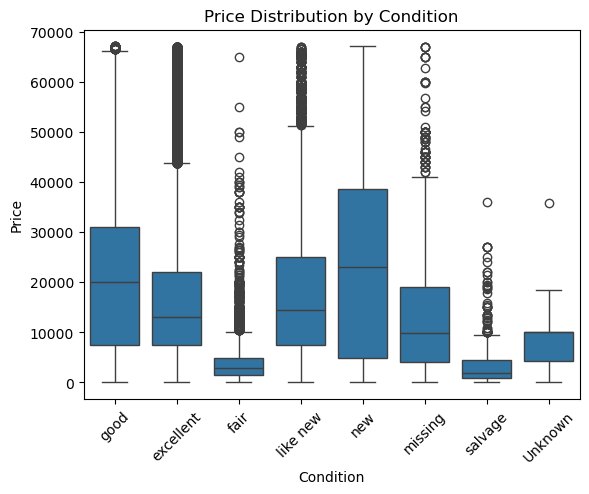

In [32]:
# Box plot for condition vs. price
boxplot= sns.boxplot(x='condition', y='price', data=data_clean)
plt.title('Price Distribution by Condition')
plt.xlabel('Condition')
plt.ylabel('Price')
plt.xticks(rotation=45)  # Rotate labels if necessary
plt.show()
boxplot.figure.savefig('images/box_condition_price.png')

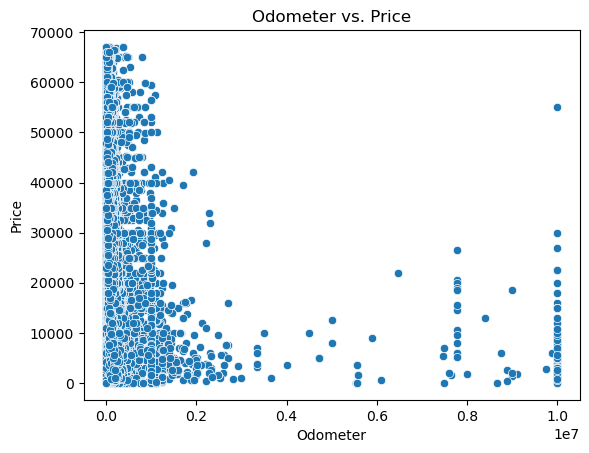

In [33]:
# Scatter plot for odometer vs. price
scatterplot = sns.scatterplot(x='odometer', y='price', data=data_clean)
plt.title('Odometer vs. Price')
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.show()
scatterplot.figure.savefig('images/scatterplot_odometer_price.png')

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

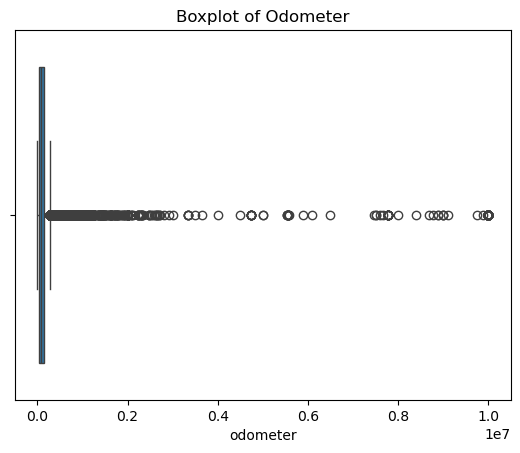

In [35]:

hist = sns.boxplot(x=data_clean['odometer'])
plt.title('Boxplot of Odometer')
plt.show()
hist.figure.savefig('images/boxplot_odometer_withOL.png')

In [36]:
# Calculate Z-scores for odometer
data_clean['odometer_zscore'] = zscore(data_clean['odometer'])

# Identify rows where the Z-score is greater than 3 or less than -3
outliers = data_clean[data_clean['odometer_zscore'].abs() > 3 ]

upper_cap = data_clean['odometer'].quantile(0.95)
data_clean['odometer'] = data_clean['odometer'].apply(lambda x: min(x, upper_cap))

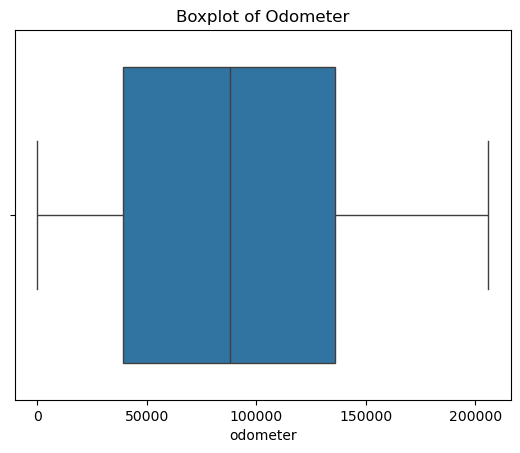

In [37]:
hist= sns.boxplot(x=data_clean['odometer'])
plt.title('Boxplot of Odometer')
plt.show()
hist.figure.savefig('images/boxplot_odometer_withoutOL.png')

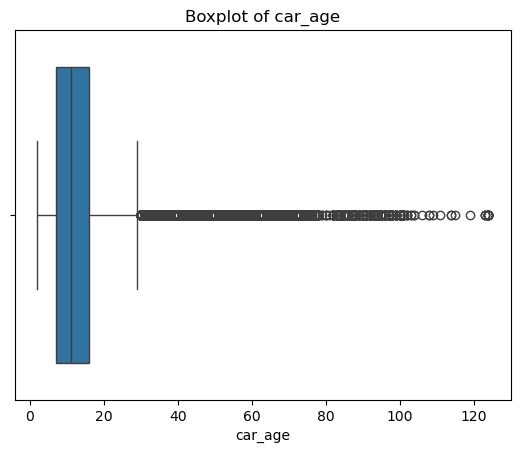

In [38]:
sns.boxplot(x=data_clean['car_age'])
plt.title('Boxplot of car_age')
plt.show()

In [39]:
data_clean['car_age_zscore'] = zscore(data_clean['car_age'])

# Identify rows where the Z-score is greater than 3 or less than -3
outliers = data_clean[data_clean['car_age_zscore'].abs() > 3 ]

upper_cap = data_clean['car_age'].quantile(0.95)
data_clean['car_age'] = data_clean['car_age'].apply(lambda x: min(x, upper_cap)).astype(int)


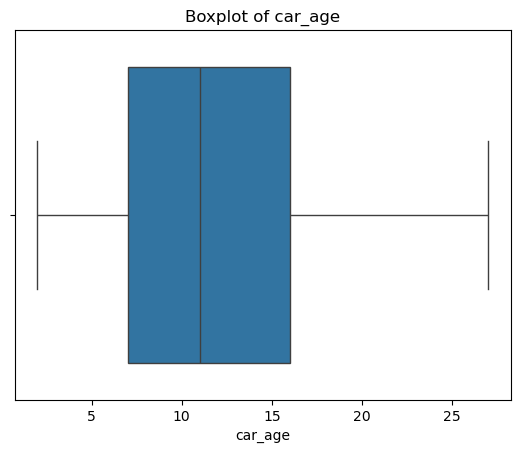

In [40]:
sns.boxplot(x=data_clean['car_age'])
plt.title('Boxplot of car_age')
plt.show()

In [41]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387530 entries, 0 to 387529
Data columns (total 41 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   region               387530 non-null  object  
 1   price                387530 non-null  int64   
 2   year                 387530 non-null  int32   
 3   manufacturer         371945 non-null  object  
 4   model                383111 non-null  object  
 5   condition            387530 non-null  object  
 6   fuel                 385233 non-null  object  
 7   odometer             387530 non-null  float64 
 8   title_status         380175 non-null  object  
 9   transmission         386034 non-null  object  
 10  drive                387530 non-null  object  
 11  type                 302924 non-null  object  
 12  paint_color          272669 non-null  object  
 13  state                387530 non-null  object  
 14  odometer_range       386436 non-null  category
 15  

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [43]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import lasso_path

In [44]:
#Define the features (X) and target variable (y)
#X = data_clean[['car_age', 'odometer'] + [col for col in data_clean.columns if 'condition_' in col or 'drive_' in col]]  # Features (including one-hot encoded columns)
X = data_clean[['car_age', 'odometer'] + [col for col in data_clean.columns if 'condition_' in col or 'drive_' in col] ] # Features (including one-hot encoded columns)

y = data_clean['price']  # Target variable (price)

# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [120]:
# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standard scaling of features
    ('regressor', LinearRegression())  # Linear Regression model
])

# Define the hyperparameter grid
param_grid = {
    'regressor__fit_intercept': [True, False],  # Hyperparameter for intercept
}

# Set up the GridSearchCV with cross-validation (5-fold cross-validation)
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters from GridSearchCV
print("Best Hyperparameters from GridSearchCV:", grid_search.best_params_)

# Predict using the best model
best_regressor = best_model.named_steps['regressor']
best_model_linear_reg = grid_search.best_estimator_
linear_reg_coefficients = best_regressor.coef_
linear_reg_features = X.columns


print("Best Hyperparameters from GridSearchCV:", grid_search.best_params_)
print("\nIntercept:", best_regressor.intercept_)
print("\nCoefficients:")

# Interpreting coefficients
for feature, coef in zip(linear_reg_features, linear_reg_coefficients):
    direction = "positive" if coef > 0 else "negative"
    print(f"Feature: {feature} | Coefficient: {coef:.2f} ({direction})")

y_pred = best_model.predict(X_test)

# Evaluate the model with RMSE
rmse_1 = mean_squared_error(y_test, y_pred)  # RMSE for evaluation
print(f"Root Mean Squared Error (RMSE): {rmse_1}")

#Lets also find the R2- score - proportion of variance in the dependent variable 
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

#Mean absolute error 
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")


Best Hyperparameters from GridSearchCV: {'regressor__fit_intercept': True}
Best Hyperparameters from GridSearchCV: {'regressor__fit_intercept': True}

Intercept: 18198.021091915463

Coefficients:
Feature: car_age | Coefficient: -4961.73 (negative)
Feature: odometer | Coefficient: -4216.28 (negative)
Feature: condition_Unknown | Coefficient: -86.28 (negative)
Feature: condition_excellent | Coefficient: -0.00 (negative)
Feature: condition_fair | Coefficient: -234.06 (negative)
Feature: condition_good | Coefficient: 1030.31 (positive)
Feature: condition_like_new | Coefficient: -101.47 (negative)
Feature: condition_missing | Coefficient: -423.29 (negative)
Feature: condition_new | Coefficient: -160.51 (negative)
Feature: condition_salvage | Coefficient: -200.90 (negative)
Feature: drive_4wd | Coefficient: 2341.96 (positive)
Feature: drive_Unknown | Coefficient: -0.00 (negative)
Feature: drive_fwd | Coefficient: -2511.51 (negative)
Feature: drive_rwd | Coefficient: 1295.36 (positive)
Root M

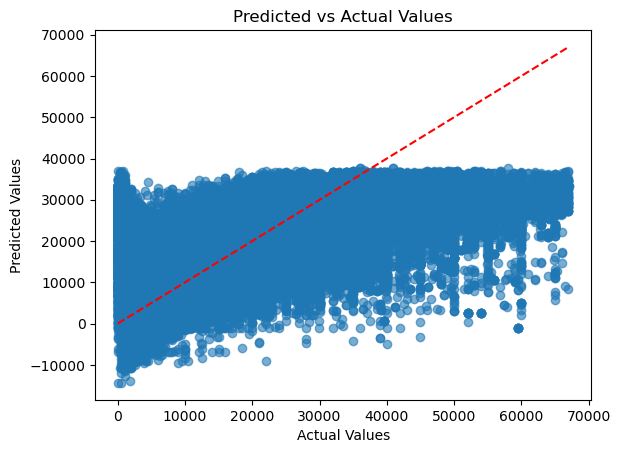

In [46]:
# Plots for understanding model performance and accuracy
# Lets compare the predicted and actual values 

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.title("Predicted vs Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()



Best Hyperparameters from GridSearchCV: {'regressor__alpha': 10.0, 'regressor__fit_intercept': True}
Best Hyperparameters from GridSearchCV: {'regressor__alpha': 10.0, 'regressor__fit_intercept': True}

Intercept: 18198.021091915463

Coefficients:
Feature: car_age | Coefficient: -4961.73 (negative)
Feature: odometer | Coefficient: -4216.28 (negative)
Feature: condition_Unknown | Coefficient: -86.28 (negative)
Feature: condition_excellent | Coefficient: -0.00 (negative)
Feature: condition_fair | Coefficient: -234.06 (negative)
Feature: condition_good | Coefficient: 1030.31 (positive)
Feature: condition_like_new | Coefficient: -101.47 (negative)
Feature: condition_missing | Coefficient: -423.29 (negative)
Feature: condition_new | Coefficient: -160.51 (negative)
Feature: condition_salvage | Coefficient: -200.90 (negative)
Feature: drive_4wd | Coefficient: 2341.96 (positive)
Feature: drive_Unknown | Coefficient: -0.00 (negative)
Feature: drive_fwd | Coefficient: -2511.51 (negative)
Feature

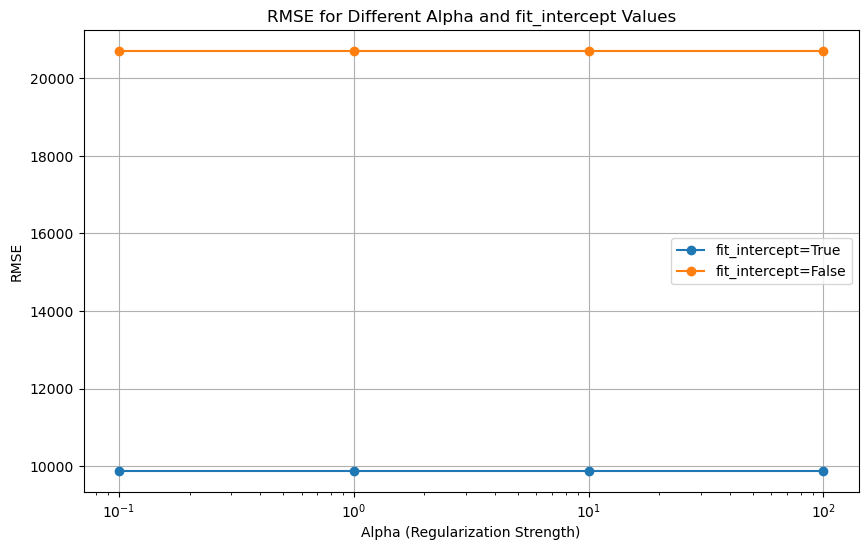

In [122]:
#The above linear regression model seems not performning well considering the RSME is too high.

X = data_clean[['car_age', 'odometer'] + [col for col in data_clean.columns if 'condition_' in col or 'drive_' in col] ] #independent variable
y = data_clean['price']  # target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with StandardScaler and Ridge Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),          # Standardize the data
    ('regressor', Ridge())                 # Ridge regression model
])

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0],  # Regularization strength for Ridge
    'regressor__fit_intercept': [True, False]  # Whether to fit an intercept or not
}

# Set up GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)

# Fit the model on the training data
grid_search.fit(X_train, y_train)


# Get the best hyperparameters
print("Best Hyperparameters from GridSearchCV:", grid_search.best_params_)

# Predict using the best model
best_regressor = best_model.named_steps['regressor']
best_model_ridge = grid_search.best_estimator_
ridge_coefficients = best_regressor.coef_
ridge_features = X.columns


print("Best Hyperparameters from GridSearchCV:", grid_search.best_params_)
print("\nIntercept:", best_regressor.intercept_)
print("\nCoefficients:")

# Interpreting coefficients
for feature, coef in zip(ridge_features, ridge_coefficients):
    direction = "positive" if coef > 0 else "negative"
    print(f"Feature: {feature} | Coefficient: {coef:.2f} ({direction})")

# Predict on the test set
y_pred = grid_search.predict(X_test)

# Calculate RMSE (Root Mean Squared Error)
rmse = mean_squared_error(y_test, y_pred)
print("Root Mean Squared Error (RMSE):", rmse)

#Lets also find the R2- score - proportion of variance in the dependent variable 
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

#Mean absolute error 
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

# Extract cv_results_
results_df = pd.DataFrame(grid_search.cv_results_)

# Filter the relevant columns from the cv_results_ DataFrame
results_df = results_df[['param_regressor__alpha', 'param_regressor__fit_intercept', 'mean_test_score']]

# Convert the mean_test_score to RMSE (since it is negative MSE)
results_df['RMSE'] = np.sqrt(-results_df['mean_test_score'])

# Plotting
plt.figure(figsize=(10, 6))

# Loop through unique values of fit_intercept and plot the results for each
for intercept in results_df['param_regressor__fit_intercept'].unique():
    subset = results_df[results_df['param_regressor__fit_intercept'] == intercept]
    
    plt.plot(subset['param_regressor__alpha'], subset['RMSE'], label=f'fit_intercept={intercept}', marker='o')

plt.xscale('log')  # Log scale for alpha to make the plot more readable
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('RMSE')
plt.title('RMSE for Different Alpha and fit_intercept Values')
plt.legend()
plt.grid(True)
plt.show()



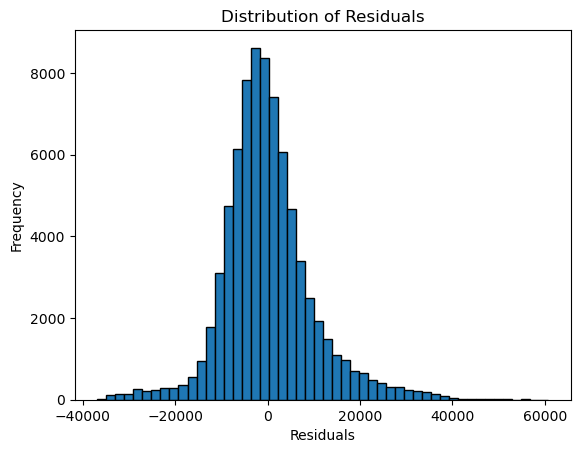

In [48]:
# Calculate residuals
residuals = y_test - y_pred

# Plot histogram of residuals
plt.hist(residuals, bins=50, edgecolor='k')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()


In [124]:
#the above Ridge model is not performaning as MSE is too high, lets try the Lasso model 

X = data_clean[['car_age', 'odometer'] + [col for col in data_clean.columns if 'condition_' in col or 'drive_' in col] ] #independent variable
y = data_clean['price']  # Target variable

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with StandardScaler and Lasso model
pipeline = Pipeline([
    ('scaler', StandardScaler()),   # Standardize the features
    ('regressor', Lasso(max_iter=100000))          # Lasso Regression model
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0],  # Regularization strength
    'regressor__fit_intercept': [True, False]         # Whether to calculate the intercept
}

# Apply GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Predict using the best model
best_regressor = best_model.named_steps['regressor']
best_model_lasso = grid_search.best_estimator_
lasso_coefficients = best_regressor.coef_
lasso_features = X.columns


print("Best Hyperparameters from GridSearchCV:", grid_search.best_params_)
print("\nIntercept:", best_regressor.intercept_)
print("\nCoefficients:")

# Interpreting coefficients
for feature, coef in zip(lasso_features, lasso_coefficients):
    direction = "positive" if coef > 0 else "negative"
    print(f"Feature: {feature} | Coefficient: {coef:.2f} ({direction})")


# Make predictions using the best model
y_pred = best_model.predict(X_test)
 

# Calculate the RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Output the results
print("Best Hyperparameters from GridSearchCV:", grid_search.best_params_)
print("Root Mean Squared Error (RMSE):", rmse)

#Lets also find the R2- score - proportion of variance in the dependent variable 
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

Best Hyperparameters from GridSearchCV: {'regressor__alpha': 0.1, 'regressor__fit_intercept': True}

Intercept: 18198.021091915463

Coefficients:
Feature: car_age | Coefficient: -4961.73 (negative)
Feature: odometer | Coefficient: -4216.28 (negative)
Feature: condition_Unknown | Coefficient: -86.28 (negative)
Feature: condition_excellent | Coefficient: -0.00 (negative)
Feature: condition_fair | Coefficient: -234.06 (negative)
Feature: condition_good | Coefficient: 1030.31 (positive)
Feature: condition_like_new | Coefficient: -101.47 (negative)
Feature: condition_missing | Coefficient: -423.29 (negative)
Feature: condition_new | Coefficient: -160.51 (negative)
Feature: condition_salvage | Coefficient: -200.90 (negative)
Feature: drive_4wd | Coefficient: 2341.96 (positive)
Feature: drive_Unknown | Coefficient: -0.00 (negative)
Feature: drive_fwd | Coefficient: -2511.51 (negative)
Feature: drive_rwd | Coefficient: 1295.36 (positive)
Best Hyperparameters from GridSearchCV: {'regressor__alp

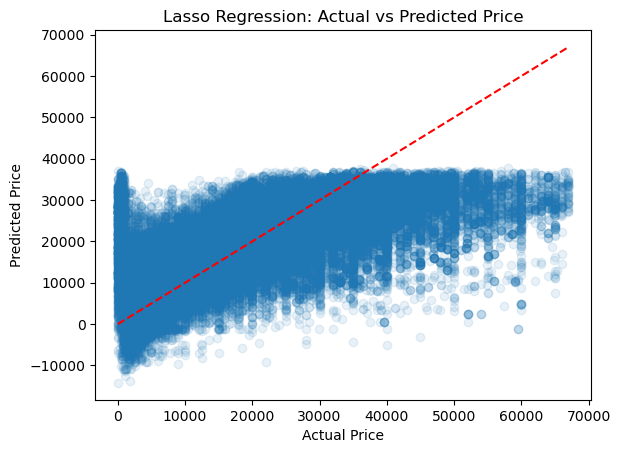

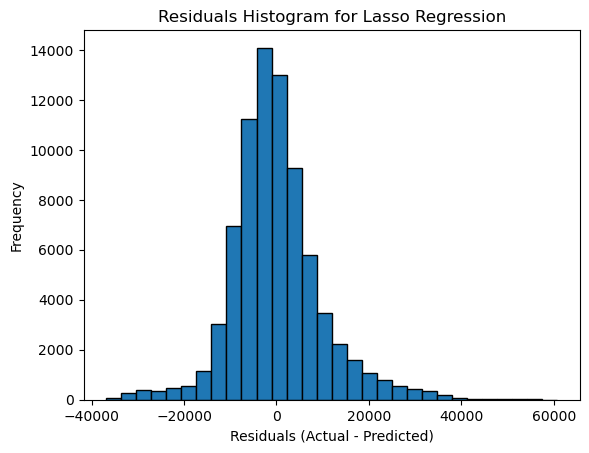

In [50]:
# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred, alpha=0.1)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Lasso Regression: Actual vs Predicted Price')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()

# Calculate residuals
residuals = y_test - y_pred

# Plot histogram of residuals
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Residuals Histogram for Lasso Regression')
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

## As per our objective of identifying the key drivers that influence used car prices. 
We need to understand how each of the factors will help provide insights for setting competitive prices and optimizing inventory management

We used 3 models here 1. Linear Regression 2. Ridge Regression 3. Lasso Regression 
Below are the Metrics Evaluation for each of them:

### Linear Regression: 
	RMSE: 96,617,279
	R²: 0.462
	MAE: 7,041
The above metrics shows that moderate prediction accuracy. The scatter plot indicates error in predictions of prices as the points are not closely aligned with the diagonal line of linear regression.

### Ridge Regression: 
	RMSE: 96,253,632
	R²: 0.463
	MAE: 7,036
Similar to Linear Regression, even with regularization not significantly improving the model performance. However the results are consistent for RMSE even with different alpha values. 
Seems regularization had not given any uplift in model performance. The residual histogram also confirms variability in predictions errors. 
Tails of graphs show higher prediction errors and maybe it is struggling with available data

### Lasso Regression: 
	RMSE: 9,811 (Best performance)
	R²: 0.463
	MAE: 7,010
***Lasso seems to offers the best prediction accuracy*** with lowest RMSE as compared to Linear and Ridge regression, but the model do not predict well considering the variance where around 46% of variance in car prices. 
Both graph ( scatter and histogram ) confirms that model performance is skewed for certain set of data.

***Business objective*** was to understand the drivers of used car prices and build a model that can predict used car prices effectively. 

***Findings***
We used the above 3 models and based on the data Lasso regression appears to be the most effective in terms of predictive accuracy due to the significantly lower RMSE. However the **R2 score** for each model suggests that model are not capturing most of the variance in the target variables,
approximately **50%** of predicted values are either **underpredicted or overpredicted**. **Using regulatization with hyperparameters also did not help in improving the performance of model**. This indicate that the model might not be providing meaningful insights or relevance about the factors that influences the used car prices. Keys insights based on the ***model coefficients*** are,
- ***Car_age and odometer*** have the largest impact on used car price. Car with higher mileage have lesser price due to wear and tear. Similarly older cars have less value compared to new ones.
- Categorical feature like car ***condition*** suggest that car with good conditions are priced higher as compared with condition like new. 
- Car with ***4 wheel drive*** are priced higher then car with front wheel(FWD) and rear wheel drive(RWD). 

Even though linear regression provides some insights on the car price, the predictive accuracy is not high enough to provide reliable pricing for unseen cars that gets added to inventory. Overall conclusion is all the 3 models do not give us required confidence that the factor chosen are deriving and predicting car prices. **The results seems to be inconclusive.** 

***Recommendation***
To be more conclusive on the drivers for the car price, we might want to used different models that could explain more variance. 
We need to revist or add certain features in the models along with their correlation to draw better insights. Maybe adding another features or computing certain feature maybe lead us to better model accuracy. Considering the R2 score, maybe using more complex models to capture more of the variance in price variable will be effective. Further hyperparameter tuning might help us overcome underfitting and overfitting of model. 


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.